In [86]:
import uproot
import awkward as ak
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/xzcqsfhu/lundtoptagger/")
from plotting.utils_plots_matplotlib import hist_with_errors
from tools.GNN_model_weight.utils_newdata import JSD

In [87]:
# Use YOUR verified score files
path_0p5 = "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/scores/statistical_study/eta0_1.2_pt160_1300_0.5%/Final_Scores_SRJ_0.25%_test_kTNone.root"
path_1p0 = "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/scores/statistical_study/eta0_1.2_pt160_1300_1.0%/Final_Scores_SRJ_0.25%_test_kTNone.root"

score_files_paths = [path_0p5, path_1p0]

# Your project meta.json
json_file = ["/home/xzcqsfhu/lundtoptagger/meta.json"]
tree_name = "FlatSubstructureJetTree"

In [88]:
import json

# Load metadata from the json file specified in the previous cell
with open(json_file[0], 'r') as f:
    meta_data = json.load(f)

dsid_numerators = {}

if "by_dsid" in meta_data:
    for dsid, values_list in meta_data["by_dsid"].items():
        if isinstance(values_list, list) and len(values_list) > 0:
            values = values_list[0]
            
            xsec = values.get('cross_section_pb', values.get('xsec'))
            genfilteff = values.get('genFiltEff', values.get('genfilteff'))
            kfactor = values.get('kfactor', 1.0)
            
            if xsec is not None and genfilteff is not None:
                # Store numerator = xsec * genfilteff * kfactor
                # sum_of_weight is not in JSON, will be calculated from data
                dsid_numerators[int(dsid)] = xsec * genfilteff * kfactor
            else:
                 print(f"Warning: Missing required values for dsid {dsid}. Found keys: {list(values.keys())}")
else:
    print("Error: 'by_dsid' key not found in JSON data")

print(f"Created dsid_numerators with {len(dsid_numerators)} entries")

Created dsid_numerators with 13 entries


In [89]:
# dsid_weight_map = {    
#     # 364700: , 78050000000.0 * 0.9753257 / 
#     # 364701: , # To be calculated
#     364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
#     364703: 26452000.0   * 0.011653  / 24.124114769654568,
#     364704: 254610.0 * 0.013358 / 0.6689032716609136,
#     364705: 4553.5   * 0.014513 / 0.021711071504255608, 
#     364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
#     364707: 16.214 * 0.011092 / 7.647190915207464e-05,
#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803
# }
# for key, val in dsid_weight_map.items():
#     print(f"key: {key}, val: {val}")

# Manual dsid_weight_map commented out to use the one calculated from the json file above
# dsid_weight_map = {
#     364703: 12823.94988,
#     364704: 5081.45927,
#     364705: 3017.75098,
#     364706: 4371.00012,
#     364707: 2349.98631,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803,
#     801661: 1.0,
#     364702: 1.0,

#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
# }

In [90]:
# 1. Load base kinematics and labels from the first file
# Use path_0p5 (defined earlier) as the base
data = uproot.open(path_0p5 + ":" + tree_name).arrays([
    "fjet_m", "fjet_pt", "fjet_eta", "labels", 
    "EventInfo_mcEventWeight", "EventInfo_mcChannelNumber"
])

# 2. Add the 0.5% score column
# We flatten it to avoid the dictionary/record errors from before
data["score_0p5"] = ak.to_numpy(
    uproot.open(path_0p5 + ":" + tree_name).arrays(["fjet_LundNet_SRJ_eta12_pt160_1300_e17_score"])
).flatten()

# 3. Add the 1.0% score column from the other file
data["score_1p0"] = ak.to_numpy(
    uproot.open(path_1p0 + ":" + tree_name).arrays(["fjet_LundNet_SRJ_eta12_pt160_1300_e19_score"])
).flatten()

# 4. Now display fields - you should see 'score_0p5' and 'score_1p0'
print("Success! Available fields:", data.fields)

Success! Available fields: ['fjet_m', 'fjet_pt', 'fjet_eta', 'labels', 'EventInfo_mcEventWeight', 'EventInfo_mcChannelNumber', 'score_0p5', 'score_1p0']


In [91]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))

Signal jets: 770889
Background jets: 902513
Total: 1673402


In [92]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# Per instructions: Using weight map based ONLY on numerators (effectively assuming sum_of_weights = 1)

mc_channel_number = ak.to_numpy(data["EventInfo_mcChannelNumber"])
mc_event_weight = ak.to_numpy(data["EventInfo_mcEventWeight"])
unique_dsids = np.unique(mc_channel_number)

# 1. Determine weight factors per DSID
dsid_factors = {}

for dsid in unique_dsids:
    # Just use the numerator: xsec * genfilteff * kfactor
    dsid_factors[int(dsid)] = dsid_numerators.get(int(dsid), 0.0)

# 2. Apply weights
# Initialize weights array
weights = np.zeros_like(mc_event_weight)

# Apply factor for each DSID
for dsid, factor in dsid_factors.items():
    mask = (mc_channel_number == dsid)
    weights[mask] = factor * mc_event_weight[mask]

print(f"Calculated weights for {len(weights)} events using only numerators.")
print(f"Mean weight: {np.mean(weights)}")
print(weights[:20])

Calculated weights for 1673402 events using only numerators.
Mean weight: 0.9060618091754387
[ 363.69654852  368.23914496  460.80884275 1026.89925896  639.69372192
  785.49108434  272.07292671  534.40843819 1240.15405619  628.70494072
  628.70494072  343.18836338  545.77121492  467.91501962 1021.79532003
  764.14042714  797.37321199 2283.75775017  423.46498805  348.87289456]


In [93]:
dsid_weight_map = {    
    364700: 1.0,               
    364701: 1.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

In [94]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# dsid_weight_map contains the pre-calculated factor (xsec * genfilteff * kfactor / sum_of_weight)
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

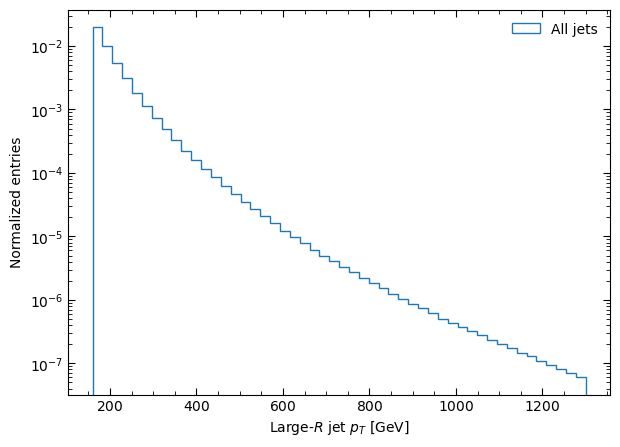

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5), dpi=100)
plt.hist(data["fjet_pt"], weights=weights, bins=50, range=(160, 1300), density=True, histtype="step", label="All jets")
plt.xlabel(r"Large-$R$ jet $p_T$ [GeV]")
plt.ylabel("Normalized entries")
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

In [96]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [97]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN3X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN3X_pqcd"],
        data["GN3X_phbb"],
        data["GN3X_phcc"],
        data["GN3X_ptop"],
        step=0.01
    )
    print(f"GN3X best AUC: {GN3X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN3X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [98]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05

try:
    if "GN3X_pqcd" in data.fields:
        pqcd = data["GN3X_pqcd"]
    else:
        # Calculate pqcd as sum of components if not present
        pqcd = data["GN3X_pqcdbb"] + data["GN3X_pqcdbx"] + data["GN3X_pqcdcx"] + data["GN3X_pqcdll"]

    denoms = fhbb * data["GN3X_phbb"] + fhcc * data["GN3X_phcc"] + (1 - fhbb - fhcc) * pqcd
    gn3x_scores = np.log(data["GN3X_ptop"] / denoms)
except Exception as e:
    print(f"Error calculating GN3X scores: {e}")
    gn3x_scores = None

Error calculating GN3X scores: no field 'GN3X_pqcdbb' in record with 8 fields


In [99]:
models = {
    "LundNet (0.5% Stats)": {
        "scores": data["score_0p5"]
    },
    "LundNet (1.0% Stats)": {
        "scores": data["score_1p0"]
    }
}

# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

In [100]:
# Access the specific field name to get the raw floating point values
# This "unwraps" the structured array into a standard 1D array of floats
data_score_0p5 = ak.to_numpy(data["score_0p5"]["fjet_LundNet_SRJ_eta12_pt160_1300_e17_score"])
data_score_1p0 = ak.to_numpy(data["score_1p0"]["fjet_LundNet_SRJ_eta12_pt160_1300_e19_score"])

# Labels and weights are already fine, but let's be safe
labels_np = ak.to_numpy(data["labels"])
weights_np = ak.to_numpy(weights)

# VERIFICATION: Dtype MUST be float64 now, not a record/VoidDType
print(f"0.5% Dtype: {data_score_0p5.dtype}")
print(f"First 3 scores (should be naked numbers): {data_score_0p5[:3]}")

0.5% Dtype: float64
First 3 scores (should be naked numbers): [0.91022408 0.26388434 0.83122408]


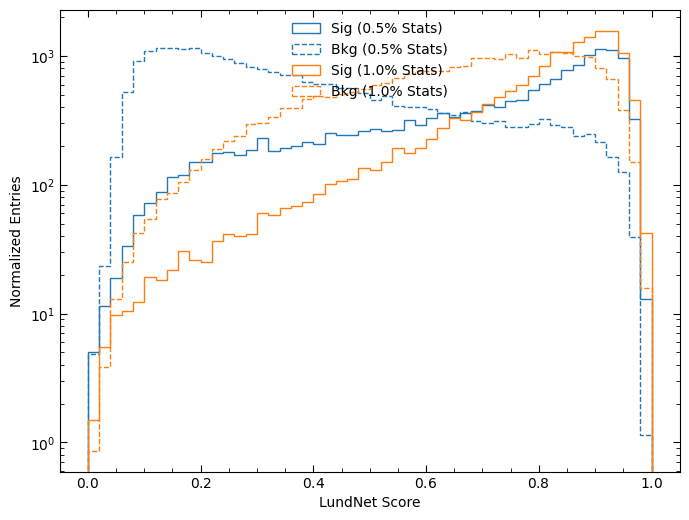

In [101]:
plt.figure(figsize=(8, 6))

# 0.5% Model (Blue)
plt.hist(data_score_0p5[labels_np==1], weights=weights_np[labels_np==1], 
         bins=50, range=(0,1), histtype="step", label="Sig (0.5% Stats)", color='C0')
plt.hist(data_score_0p5[labels_np==0], weights=weights_np[labels_np==0], 
         bins=50, range=(0,1), histtype="step", label="Bkg (0.5% Stats)", ls="--", color='C0')

# 1.0% Model (Orange)
plt.hist(data_score_1p0[labels_np==1], weights=weights_np[labels_np==1], 
         bins=50, range=(0,1), histtype="step", label="Sig (1.0% Stats)", color='C1')
plt.hist(data_score_1p0[labels_np==0], weights=weights_np[labels_np==0], 
         bins=50, range=(0,1), histtype="step", label="Bkg (1.0% Stats)", ls="--", color='C1')

plt.yscale("log")
plt.xlabel("LundNet Score")
plt.ylabel("Normalized Entries")
plt.legend(frameon=False, loc='upper center')
plt.show()

In [102]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    if scores is None:
        print(f"Skipping {model} because scores are None")
        continue

    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet (0.5% Stats): {fjet_LundNet_SRJ_eta12_pt160_1300_e17_score: 0.765}
50% signal efficiency threshold for LundNet (1.0% Stats): {fjet_LundNet_SRJ_eta12_pt160_1300_e19_score: 0.789}


In [103]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

In [104]:
# selected_models = models.keys()  # Use all models for now
# selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
# plot_signal_after_tagging = False
# plot_errorbars = True
# calc_jsd = False

# plot_params = {
#     "lin": {
#         "yscale": "linear",
#         "ylim": (0, 0.06),
#     },
#     "log": {
#         "yscale": "log",
#         "ylim": (1e-5, 10),
#     }
# }

# for params in plot_params.values():
#     for var in var_params:
#         fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=200)

#         var_data = data[var]
#         hist_params = dict(
#             bins = var_params[var]["bins"],
#             range = var_params[var]["range"],
#             density = True,
#         )

#         # QCD background: shaded dark gray with black outline
#         bkg_counts = plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], label="QCD background", color="dimgray", alpha=0.7, **hist_params)[0]
#         plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], histtype="step", color="black", linewidth=1.2, **hist_params)
#         # Signal: fill with neutral, light colour
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], label="Signal", color="lightsteelblue", alpha=0.6, **hist_params)
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], histtype="step", color="slategray", linewidth=1.2, **hist_params)

#         for i, model in enumerate(selected_models):
#             tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

#             if i !=0 and calc_jsd:
#                 bkg_counts_tagged = np.histogram(
#                     ak.to_numpy(var_data[(labels==0) & tagged_as_signal & selection]),
#                     weights=ak.to_numpy(weights[(labels==0) & tagged_as_signal & selection]),
#                     **hist_params
#                 )[0]
#                 JSD_value = JSD(bkg_counts, bkg_counts_tagged)*100  # TODO: maybe shouldn't be expressed as a percentage
#                 JSD_label = f", JSD = {JSD_value:.2f}%"
#             else:
#                 JSD_label = ""

#             if plot_errorbars:
#                 extra_args = dict(fmt='.')
#                 hist_plot_func = hist_with_errors
#             else:
#                 extra_args = dict(histtype="step", linestyle='-' if i==0 else '--', linewidth=1.5)
#                 hist_plot_func = plt.hist
#             hist_plot_func(
#                 var_data[(labels==0) & tagged_as_signal & selection],
#                 weights=weights[(labels==0) & tagged_as_signal & selection],
#                 label=f"QCD tagged as signal{JSD_label}\n({model})",
#                 **hist_params, **extra_args
#             )
#             if plot_signal_after_tagging:
#                 hist_plot_func(
#                     var_data[(labels==1) & tagged_as_signal & selection],
#                     weights=weights[(labels==1) & tagged_as_signal & selection],
#                     label=f"Signal tagged as signal{JSD_label}\n({model})",
#                     **hist_params, **extra_args
#                 )

#         # Add ATLAS label
#         atlas_label = r"ATLAS"
#         atlas_sim = r"Simulation Internal"
#         atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
#         jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
#         selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
#         text_args = {"transform": ax.transAxes, "va": 'top'}
#         ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
#         ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
#         ax.text(0.04, 0.92, atlas_info,     fontsize=11, **text_args)
#         ax.text(0.04, 0.87, jet_info,       fontsize=11, **text_args)
#         ax.text(0.04, 0.82, selection_info, fontsize=11, **text_args)

#         plt.xlim(var_params[var]["range"])
#         plt.xlabel(var_params[var]["title"])
#         plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
#         plt.yscale(params["yscale"])
#         plt.ylim(params["ylim"])
#         # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#         plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
#         plt.show()

In [105]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]

mass_cuts = [
    (0, float('inf')),
]
pt_min = 160
pt_max = 1300
eta_min = 0.0
eta_max = 1.2
# eta_max = float('inf')

In [107]:
# 1. Ensure labels and weights are simple numpy arrays
labels_np = ak.to_numpy(data["labels"])
weights_np = ak.to_numpy(weights)

# 2. Re-clean the models dictionary to use naked floats
# We reach into the record to get the raw <f8 (float64) values
models["LundNet (0.5% Stats)"]["scores"] = ak.to_numpy(
    data["score_0p5"]["fjet_LundNet_SRJ_eta12_pt160_1300_e17_score"]
).flatten()

models["LundNet (1.0% Stats)"]["scores"] = ak.to_numpy(
    data["score_1p0"]["fjet_LundNet_SRJ_eta12_pt160_1300_e19_score"]
).flatten()

print("Verified 0.5% score type:", models["LundNet (0.5% Stats)"]["scores"].dtype)

Verified 0.5% score type: float64


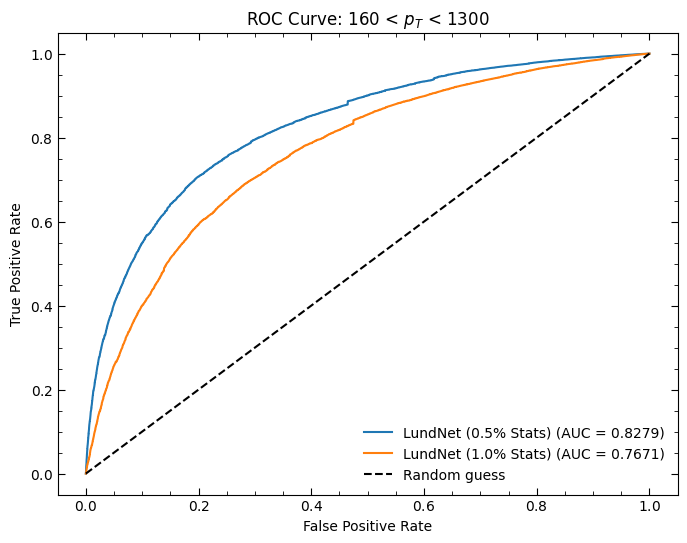

In [112]:
for mass_cut in mass_cuts:
    m_min, m_max = mass_cut
    # Ensure 'cuts' is a numpy boolean mask
    cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max) & (np.abs(eta) > eta_min)
    cuts = ak.to_numpy(cuts) 
    
    y_truth_cuts = labels_np[cuts]
    weights_cuts = weights_np[cuts]

    plt.figure(figsize=(8, 6))
    for trained_model in models:
        # Pull the now-flattened scores
        y_pred = models[trained_model]["scores"][cuts]
        
        fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
        roc_auc = auc(fpr, tpr)

        models[trained_model][f"fpr_{m_min}-{m_max}"] = fpr
        models[trained_model][f"tpr_{m_min}-{m_max}"] = tpr

        plt.plot(fpr, tpr, label=f"{trained_model} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")
    plt.title(f"ROC Curve: {pt_min} < $p_T$ < {pt_max}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", frameon=False)
    plt.show()

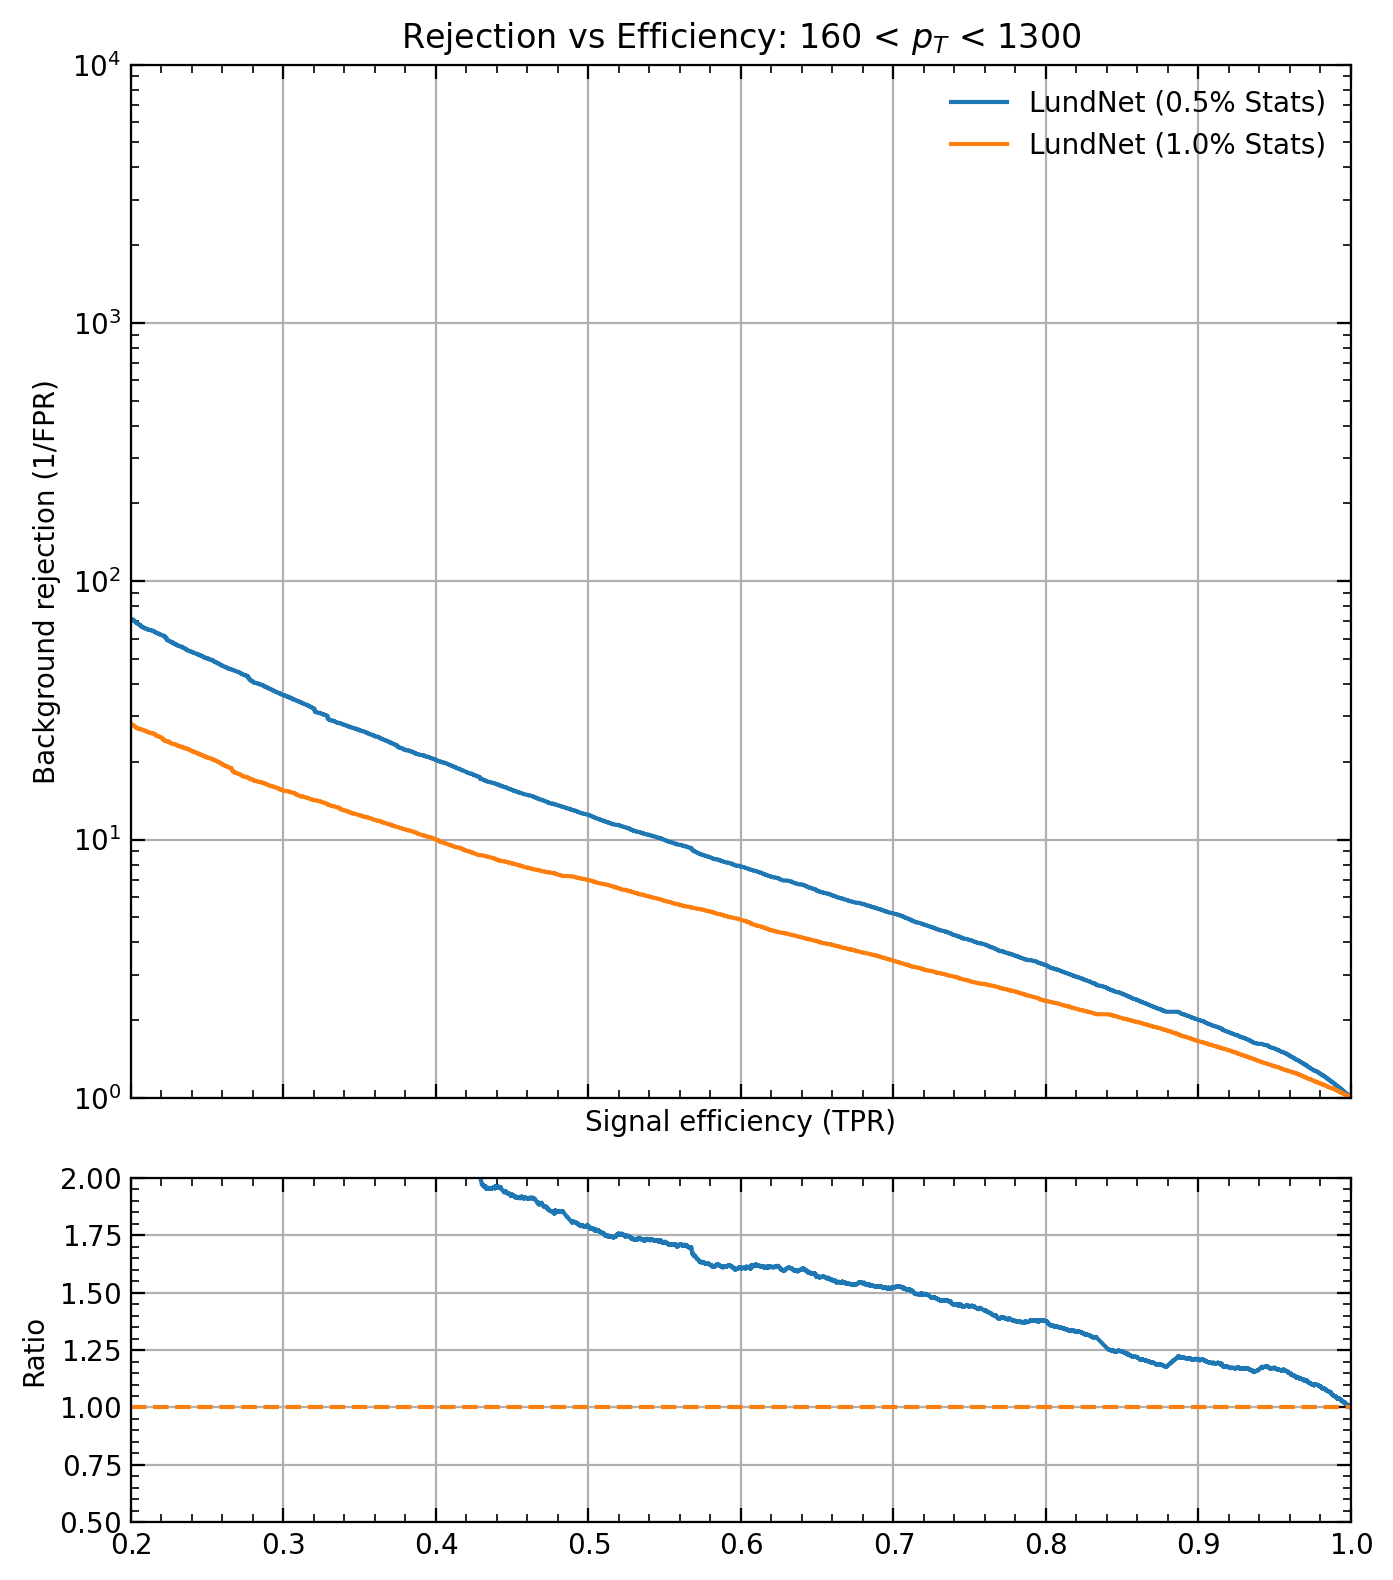

In [113]:
selected_models = list(models.keys()) 
show_grid = True
plot_ratio = True

# CHANGE: Match the key exactly to your 1.0% model
reference_model = "LundNet (1.0% Stats)" 

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for trained_model in selected_models:
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        
        # FIX: Safe division to handle infinity
        rejection = np.divide(1.0, fpr, out=np.zeros_like(fpr), where=fpr!=0)
        ax1.plot(tpr, rejection, label=f"{trained_model}")

    ax1.set_title(f"Rejection vs Efficiency: {pt_min} < $p_T$ < {pt_max}")
    ax1.set_xlabel("Signal efficiency (TPR)")
    ax1.set_ylabel("Background rejection (1/FPR)")
    ax1.set_xlim([0.2, 1])
    ax1.set_ylim([1, 1e4]) # Adjusted for visibility
    ax1.set_yscale("log")
    ax1.legend(frameon=False)

    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]
        # Safe division for reference rejection
        ref_rej = np.divide(1.0, ref_fpr, out=np.zeros_like(ref_fpr), where=ref_fpr!=0)

        for i, trained_model in enumerate(selected_models):
            color = f"C{i}"
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--")
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Safe division for current model rejection
            rej = np.divide(1.0, fpr, out=np.zeros_like(fpr), where=fpr!=0)
            
            # Interpolate to match the reference TPR points
            interp_rej = np.interp(ref_tpr, tpr, rej, left=np.nan, right=np.nan)
            ratio = np.divide(interp_rej, ref_rej, out=np.zeros_like(interp_rej), where=ref_rej!=0)
            ax2.plot(ref_tpr, ratio, label=f"Ratio to 1.0%", color=color)

        ax2.set_ylabel("Ratio")
        ax2.set_ylim([0.5, 2.0]) # Standard ratio range
        ax2.grid(show_grid)

    ax1.grid(show_grid)
    plt.tight_layout()
    plt.show()

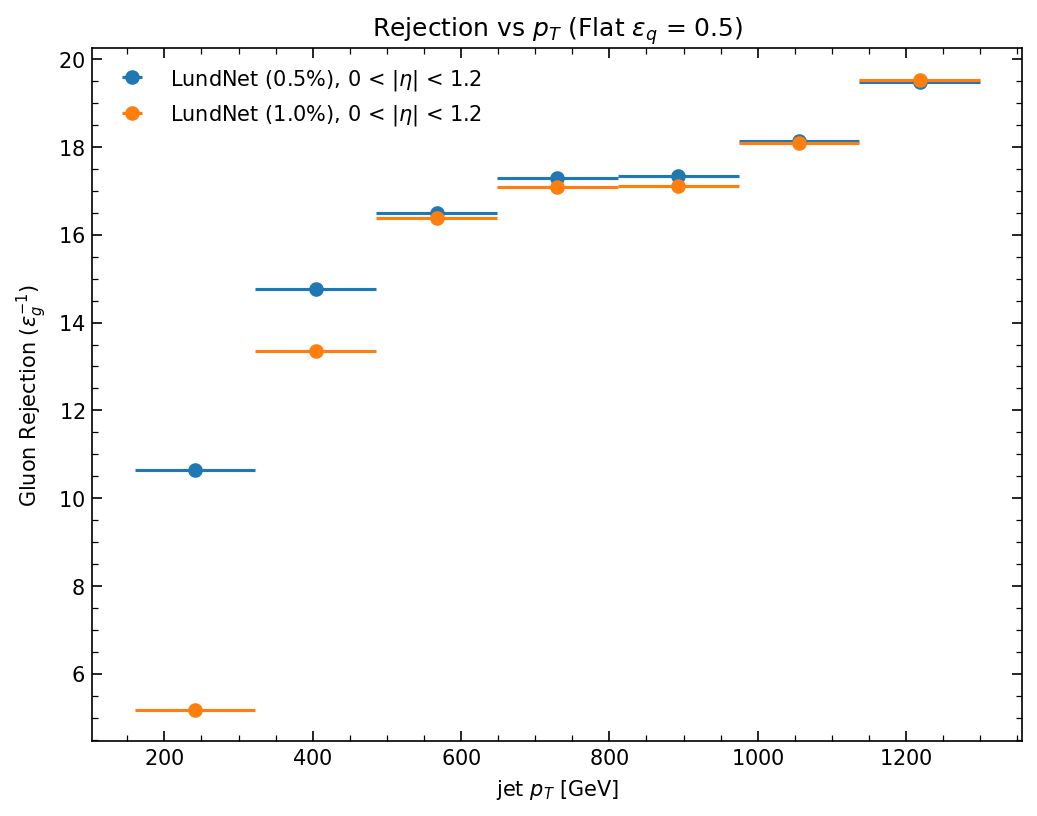

In [123]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5):
    """
    Graphs the gluon rejection (1/epsilon_g) at a fixed quark efficiency (epsilon_q) as a function of jet pT,
    with error bars derived from background statistics.
    
    Methodology:
    1. In each pT bin, determine the score threshold x_WP such that the weighted fraction of signal events 
       with score > x_WP is equal to `signal_efficiency`.
    2. Calculate the weighted fraction of background events passing this threshold (epsilon_g).
    3. Calculate rejection R = 1 / epsilon_g.
    4. Calculate statistical uncertainty on R using error propagation for weighted binomial efficiency.
    """
    pt = data["fjet_pt"]
    labels = data["labels"]
    
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    plt.figure(figsize=(8, 6), dpi=150)

    eta_range_str = "0 < |$\eta$| < 1.2"
    
    for model_name in models:
        scores = models[model_name]["scores"]
        rejections = []
        errors = []
        valid_centers = []
        valid_xerr = []
        
        # Determine display name (e.g., convert "LundNet (0.5% Stats)" to "LundNet 0.5%")
        display_name = model_name.replace(" (Stats)", "").replace(" Stats", "")

        for i in range(len(pt_bins)-1):
            p_min, p_max = pt_bins[i], pt_bins[i+1]
            mask = (pt >= p_min) & (pt < p_max)
            
            if np.sum(mask) < 10: continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask])
            w = ak.to_numpy(weights[mask])
            
            if len(np.unique(y_true)) < 2: continue
            
            # Split into signal and background
            sig_mask = (y_true == 1)
            bkg_mask = (y_true == 0)
            
            s_scores = y_score[sig_mask]
            s_weights = w[sig_mask]
            b_scores = y_score[bkg_mask]
            b_weights = w[bkg_mask]
            
            if len(s_scores) == 0 or len(b_scores) == 0: continue
            
            # 1. Determine Threshold from Signal
            # We want to keep 'signal_efficiency' fraction of signal events (highest scores)
            # Sort signal scores
            sorter = np.argsort(s_scores)
            s_scores_sorted = s_scores[sorter]
            s_weights_sorted = s_weights[sorter]
            
            cum_w = np.cumsum(s_weights_sorted)
            total_s_w = cum_w[-1]
            
            # Threshold is the score where (1 - signal_efficiency) of weight is below it
            # e.g. 50% eff -> 50% below. 80% eff -> 20% below.
            target_w = total_s_w * (1 - signal_efficiency)
            idx = np.searchsorted(cum_w, target_w)
            threshold = s_scores_sorted[min(idx, len(s_scores_sorted)-1)]
            
            # 2. Calculate Background Efficiency (FPR) and Error
            # Pass = score > threshold
            pass_mask = b_scores > threshold
            
            W_total = np.sum(b_weights)
            W_pass = np.sum(b_weights[pass_mask])
            
            if W_pass == 0:
                continue # Infinite rejection
                
            epsilon_g = W_pass / W_total
            
            # Error propagation for weighted efficiency
            # var(eps) = (1/W_tot^2) * [ (1-eps)^2 * sum(w_pass^2) + eps^2 * sum(w_fail^2) ]
            sw2_pass = np.sum(b_weights[pass_mask]**2)
            sw2_fail = np.sum(b_weights[~pass_mask]**2)
            
            var_epsilon = (1.0 / W_total**2) * ( (1 - epsilon_g)**2 * sw2_pass + epsilon_g**2 * sw2_fail )
            sigma_epsilon = np.sqrt(var_epsilon)
            
            # Rejection R = 1 / epsilon
            R = 1.0 / epsilon_g
            # sigma_R = R^2 * sigma_epsilon
            sigma_R = (R**2) * sigma_epsilon
            
            rejections.append(R)
            errors.append(sigma_R)
            valid_centers.append(bin_centers[i])
            valid_xerr.append(bin_half_widths[i])

        # Update the label to include pT and eta info
        full_label = f"{display_name}, {eta_range_str}"
            
        plt.errorbar(valid_centers, rejections, xerr=valid_xerr, fmt='o', label=full_label, capsize=0, elinewidth=1.5,)
        
    plt.xlabel(r"jet $p_T$ [GeV]")
    plt.ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    #plt.xscale("log")
    plt.legend(frameon=False)
    #plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.title(f"Rejection vs $p_T$ (Flat $\epsilon_q$ = {signal_efficiency})")
    plt.show()

# Define pT bins covering the range of interest (20 to 160 GeV)
pt_bins = np.linspace(160, 1300, 8)

# Call the function
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5)

In [ ]:
path_0p5 = "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/scores/statistical_study/eta0_1.2_pt160_1300_0.5%/Final_Scores_SRJ_0.25%_test_kTNone.root"
path_1p0 = "/home/xzcqsfhu/lundtoptagger/qg_analysis_data/scores/statistical_study/eta0_1.2_pt160_1300_1.0%/Final_Scores_SRJ_0.25%_test_kTNone.root"

with uproot.open(path_0p5) as f0, uproot.open(path_1p0) as f1:
    tree0 = f0["FlatSubstructureJetTree"]
    tree1 = f1["FlatSubstructureJetTree"]
    print(f"0.5% File Jets: {tree0.num_entries}")
    print(f"1.0% File Jets: {tree1.num_entries}")

0.5% File Jets: 1673402
1.0% File Jets: 1673402
